# Analysis of Gendered Rhetoric in French Electoral Manifestos (1973–1993)
**Methodology:** NLP, TF-IDF Vectorization, and Non-Negative Matrix Factorization (NMF)

This notebook investigates whether male and female political candidates in France utilized distinct rhetorical strategies during the late 20th century. By analyzing over 20,000 digitized manifestos, the goal is to uncover thematic "ownership" and identity-based signaling.

## I. Exploratory Data Analysis
This section focuses on data cleaning, gender distribution, and initial frequency analysis.

### 1. Data Cleaning & Filtering
We filter the dataset to include only candidates with a known gender (`homme` or `femme`). 
* **Note on Imbalance:** The corpus is historically imbalanced (approx. 9:1 male to female ratio), reflecting the political landscape of the era. To ensure valid comparisons, all subsequent thematic analysis uses **relative frequencies** and **mean topic weights** rather than raw counts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the cleaned data
df = pd.read_parquet('cleaned_master_data.parquet')

# Basic Volume Check
print(f"Total Manifestos: {len(df)}")
print("\nManifestos by Year:")
print(df['year'].value_counts().sort_index())

Total Manifestos: 21167

Manifestos by Year:
year
1973    3843
1978    4827
1981    3121
1988    3539
1993    5837
Name: count, dtype: int64


In [2]:
# Create a modeling-specific dataframe
df_modeling = df[df['titulaire-sexe'].isin(['homme', 'femme'])].copy()

print(f"Original count: {len(df)}")
print(f"Cleaned count for modeling: {len(df_modeling)}")
print(f"Dropped {len(df) - len(df_modeling)} rows with unknown gender.")

Original count: 21167
Cleaned count for modeling: 20331
Dropped 836 rows with unknown gender.


In [3]:
# Final Gender Imbalance
final_gender_counts = df_modeling['titulaire-sexe'].value_counts()
print("\nGender Distribution:")
print(final_gender_counts)


Gender Distribution:
titulaire-sexe
homme    18171
femme     2160
Name: count, dtype: int64


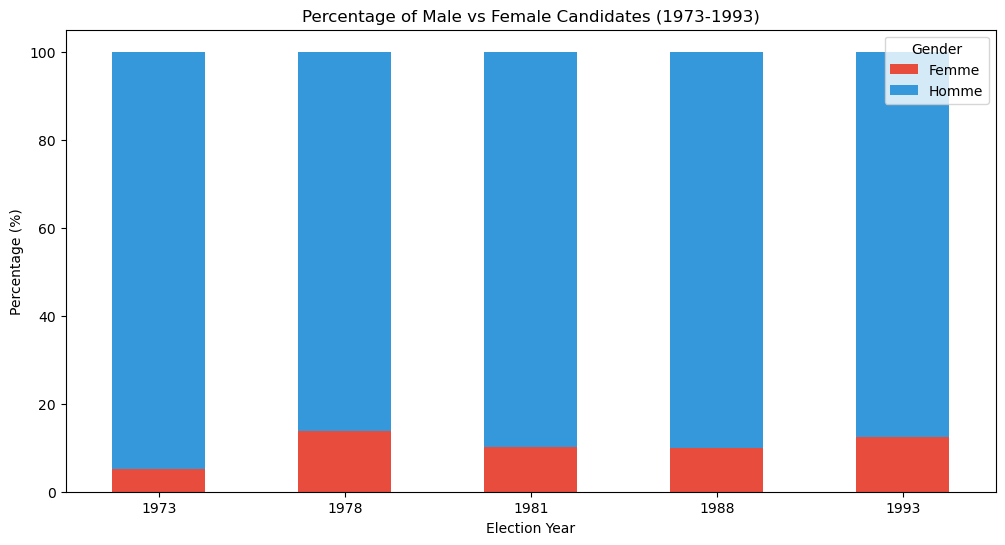

In [4]:
# Calculate percentages by year
props = df_modeling.groupby(['year', 'titulaire-sexe']).size().unstack()
props_pct = props.div(props.sum(axis=1), axis=0) * 100

# Plotting the percentage evolution
props_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#e74c3c', '#3498db'])
plt.title('Percentage of Male vs Female Candidates (1973-1993)')
plt.ylabel('Percentage (%)')
plt.xlabel('Election Year')
plt.legend(title='Gender', labels=['Femme', 'Homme'])
plt.xticks(rotation=0)
plt.show()

### 2. Lexical Diversity & Top Tokens
We compare the vocabulary variety (lexical richness) to see if one gender utilizes more complex language. 
**Key Finding:** Lexical richness is virtually identical (~0.84), suggesting that the "Manifesto" imposes a similar level of complexity on all authors regardless of gender.


Average Word Count (Cleaned Tokens):
titulaire-sexe
femme    152.584259
homme    151.729734
Name: token_length, dtype: float64


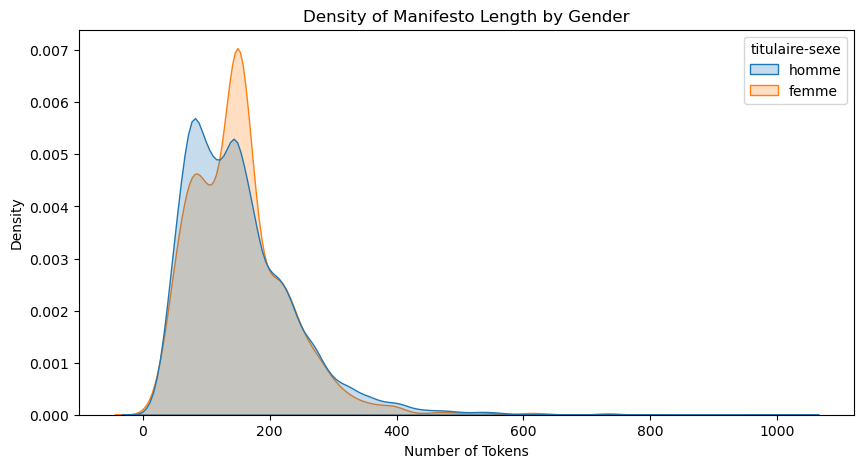

In [5]:
# Word count based on final_tokens
df_modeling['token_length'] = df_modeling['final_tokens'].str.split().str.len()

# Compare averages
avg_len = df_modeling.groupby('titulaire-sexe')['token_length'].mean()
print("\nAverage Word Count (Cleaned Tokens):")
print(avg_len)

# Visualize Distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_modeling, x="token_length", hue="titulaire-sexe", fill=True, common_norm=False)
plt.title('Density of Manifesto Length by Gender')
plt.xlabel('Number of Tokens')
plt.show()


Lexical Richness by Gender (Higher = more varied vocabulary):
titulaire-sexe
femme    0.842091
homme    0.841416
Name: lexical_richness, dtype: float64


/var/folders/5q/fx2dxhl52b3c_xdmrzcdb99m0000gn/T/ipykernel_63665/203418152.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modeling, x='titulaire-sexe', y='lexical_richness', palette='Set3')


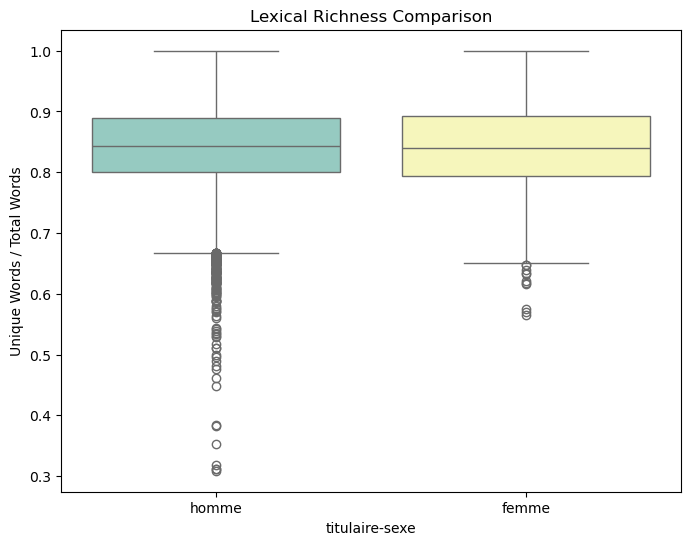

In [6]:
# Lexical richness: unique words divided by total words
df_modeling['lexical_richness'] = df_modeling['final_tokens'].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)

print("\nLexical Richness by Gender (Higher = more varied vocabulary):")
print(df_modeling.groupby('titulaire-sexe')['lexical_richness'].mean())

# Visualize with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_modeling, x='titulaire-sexe', y='lexical_richness', palette='Set3')
plt.title('Lexical Richness Comparison')
plt.ylabel('Unique Words / Total Words')
plt.show()

In [7]:
from collections import Counter
import pandas as pd

def get_top_tokens(series, n=20):
    all_tokens = [token for text in series for token in text.split()]
    return Counter(all_tokens).most_common(n)

# Generate counts
women_top = get_top_tokens(df_modeling[df_modeling['titulaire-sexe'] == 'femme']['final_tokens'])
men_top = get_top_tokens(df_modeling[df_modeling['titulaire-sexe'] == 'homme']['final_tokens'])

# Clean display
comparison_df = pd.DataFrame({
    'Rank': range(1, 21),
    'Women_Word': [word for word, count in women_top],
    'Women_Freq': [count for word, count in women_top],
    'Men_Word': [word for word, count in men_top],
    'Men_Freq': [count for word, count in men_top]
})

print(comparison_df)

    Rank        Women_Word  Women_Freq          Men_Word  Men_Freq
0      1       travailleur        5575       travailleur     18390
1      2             femme        4204             union     17936
2      3           travail        2151            emploi     16785
3      4             droit        2123           travail     15193
4      5        communiste        2007             homme     15165
5      6             homme        1974        socialiste     14505
6      7            emploi        1849             droit     13278
7      8        socialiste        1717        communiste     13111
8      9             union        1579        entreprise     12394
9     10        entreprise        1399         confiance     11748
10    11           chômage        1301             maire     11740
11    12           société        1299           société     11180
12    13              voix        1179             jeune     10184
13    14  parti_socialiste        1166            région     1

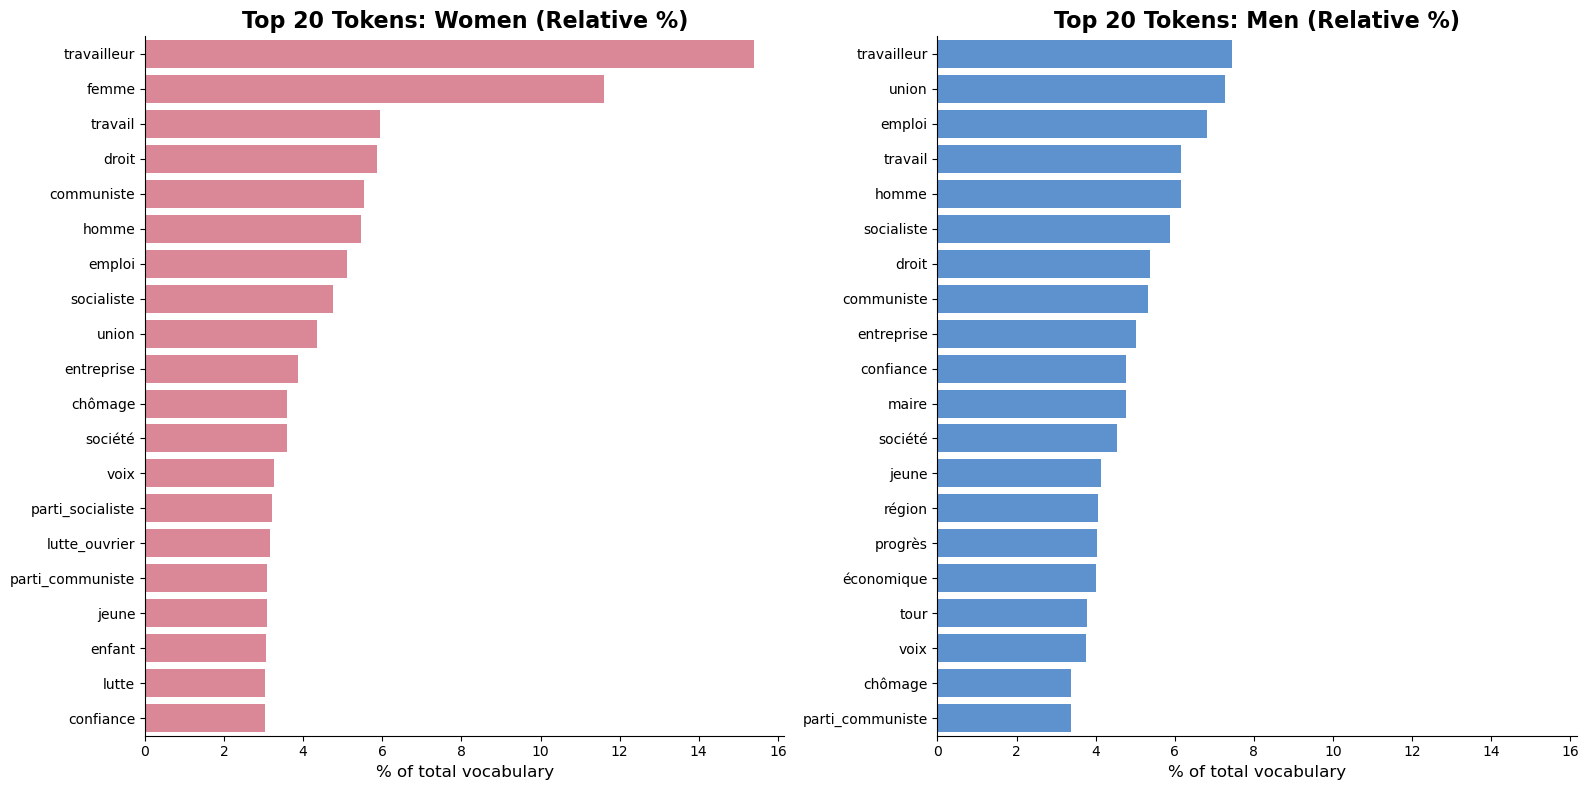

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data (Relative Frequency)
total_women_words = sum(count for word, count in women_top)
total_men_words = sum(count for word, count in men_top)

df_women = pd.DataFrame(women_top, columns=['word', 'count'])
df_women['pct'] = (df_women['count'] / total_women_words) * 100

df_men = pd.DataFrame(men_top, columns=['word', 'count'])
df_men['pct'] = (df_men['count'] / total_men_words) * 100

# Plotting with custom colors
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

# Plot for Women - Using a Salmon/Rose color
sns.barplot(data=df_women, x='pct', y='word', ax=axes[0], color='#e87a90') 
axes[0].set_title('Top 20 Tokens: Women (Relative %)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('% of total vocabulary', fontsize=12)
axes[0].set_ylabel('') # Clean up the Y axis label

# Plot for Men - Using a Steel Blue color
sns.barplot(data=df_men, x='pct', y='word', ax=axes[1], color='#4a90e2')
axes[1].set_title('Top 20 Tokens: Men (Relative %)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('% of total vocabulary', fontsize=12)
axes[1].set_ylabel('') # Clean up the Y axis label

# Final Styling
sns.despine() # Removes the top and right borders for a cleaner look
plt.tight_layout()
plt.show()

#### Some Observations:
- Both genders share `travailleur`  as their Rank 1 token, signaling the industrial and labor-focused climate of French politics between 1973 and 1993.
- For women, `femme` is the **#2 most frequent word** whereas for men, `femme` does not appear in the Top 20 at all. Instead, men prioritize `union` (#2) and `emploi` (#3).
- Men's unique Top 20 keywords:** `maire`, `région`, and `progrès`. This suggests a rhetoric built on administrative authority and territorial governance.
- Women's unique Top 20 keywords:** `enfant` (Child), `lutte_ouvrier` (Workers' Struggle), and `parti_socialiste`. This reflects a rhetoric more closely tied to social welfare and specific activist identities.

### 3. Visualizing the Rhetorical Landscape
To move beyond raw numbers, we use **Word Clouds** to visualize the "thematic weight" of each gender's vocabulary. In these clouds, word size is proportional to frequency, allowing us to see the primary pillars of their respective campaigns at a glance.

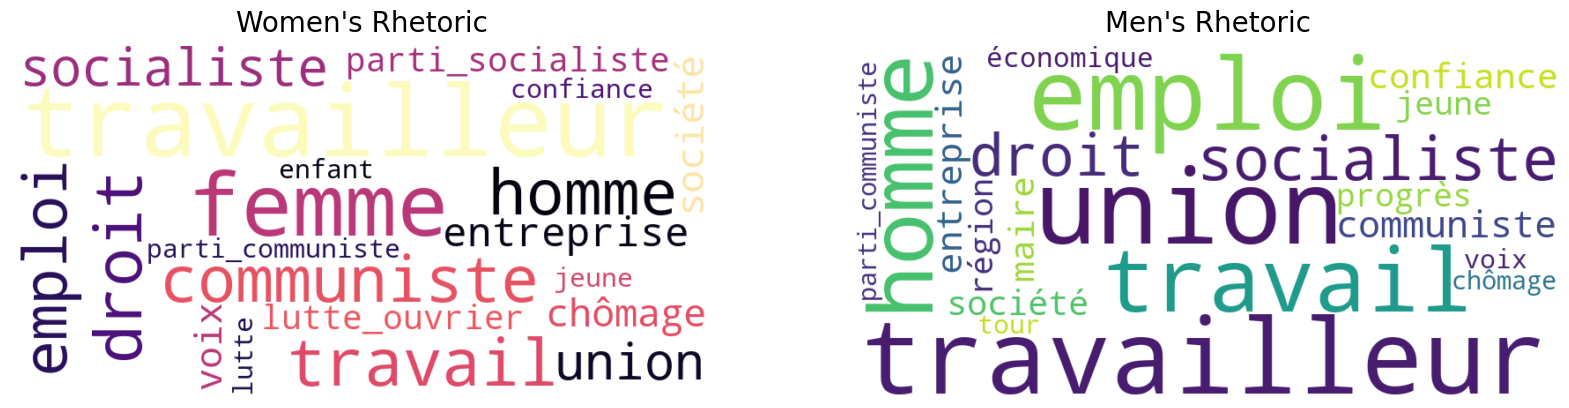

In [9]:
from wordcloud import WordCloud

# Create dictionaries of word frequencies
women_freq = dict(zip(df_women['word'], df_women['count']))
men_freq = dict(zip(df_men['word'], df_men['count']))

# Define WordCloud style
def generate_cloud(data, title, colormap):
    wc = WordCloud(
        width=800, height=400, 
        background_color='white', 
        colormap=colormap, 
        max_words=50,
        prefer_horizontal=0.7
    ).generate_from_frequencies(data)
    
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20, pad=10)
    plt.axis('off')

# Plot side-by-side
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
generate_cloud(women_freq, "Women's Rhetoric", 'magma')

plt.subplot(1, 2, 2)
generate_cloud(men_freq, "Men's Rhetoric", 'viridis')

plt.show()

## II. Topic Modeling (NMF)
We use **Non-negative Matrix Factorization (NMF)** to identify "latent" (hidden) themes. Unlike simple word counts, NMF groups words that frequently co-occur, allowing us to identify coherent political discourses.

In [10]:
# Setup and Vectorization

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# 1. Load the data
df = pd.read_parquet('cleaned_master_data.parquet')

# 2. Filter for known genders (Creating df_modeling)
df_modeling = df[df['titulaire-sexe'].isin(['homme', 'femme'])].copy()

# 3. Initialize TF-IDF Vectorizer
# We focus on the 20,331 documents now
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, min_df=5)

# 4. Create the matrix using df_modeling
tfidf_matrix = tfidf_vectorizer.fit_transform(df_modeling['final_tokens'])

print(f"Final Count for Modeling: {len(df_modeling)}")
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

Final Count for Modeling: 20331
TF-IDF Matrix Shape: (20331, 38796)


In [11]:
# Running the NMF Decomposition

# Set the number of topics
num_topics = 15

# Initialize and fit the NMF model
# random_state=42 ensures we get the same results every time we run it
nmf_model = NMF(n_components=num_topics, random_state=42, init='nndsvd')
W = nmf_model.fit_transform(tfidf_matrix)
H = nmf_model.components_

print("NMF model training complete.")

NMF model training complete.


In [12]:
# Reviewing the "Thematic Clusters"

def get_topic_words(vectorizer, model, n_words=15):
    words = vectorizer.get_feature_names_out()
    topic_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[-n_words:][::-1]
        topic_dict[f"Topic {topic_idx}"] = [words[i] for i in top_word_indices]
    return pd.DataFrame(topic_dict)

# Display the topics as a table
topics_df = get_topic_words(tfidf_vectorizer, nmf_model)
topics_df

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14
0,emploi,travailleur,front_national,front_national,entente_ecologiste,lutte_ouvrier,communiste,travailleur,lutte_ouvrier,front_national,loi,travailleur,union,nature_animal,france_unie
1,entreprise,femme,avenir_front,immigration_chômage,écologie,travailleur,parti_communiste,lutte,travailleur,public,science_védique,immigré,socialiste,rassemblement_nature,france_uni
2,travail,lutte_ouvrier,payent_député,main_propre,entent_ecologiste,chambre_député,union,autogestion,progrès,prospérité_loi,nature,grève,maire,ecologiste_rassemblement,solidarité
3,région,ouvrier_employé,différence_collègue,séjour_renouvelable,génération_ecologie,petit_paysan,voix,socialisme,service_public,avortement_suicidaire,scientifique,cumul_mandat,tour,propriété_répartition,progrès
4,droit,bombe_atomique,union_antisocialiste,carte_séjour,écologiste,travailleuse_travailleur,votant,ouvrier,ouvrier,rentier_indexation,résultat,indépendance_national,confiance,chasse_corrida,majorite_presidentiell
5,développement,paysan_petit,groupe_absent,insécurité_excès,responsable_actif,grand_capital,ministre_communiste,droit,révolutionnaire,automatique_rigoureux,système,second_tour,parti_socialiste,vivisection_question,exclusion
6,homme,lutte_ouvrière,populaire_fidèle,sauver_agriculture,homme_morale,homme,travailleur,travail,professeur,élémentaire_urgent,méditation_transcendantal,tour,conseiller_général,travail_garanti,ouverture
7,économique,marchais,terre_réduction,fiscal_corruption,souffle_vie,intérêt,rassemblement,populaire,tour,constitution_véritable,graine_récolte,mandat,suffrage,candidat_trouvent,revenu_minimum
8,jeune,petit_commerçant,conviction_promesse,immigré_garantir,manière_difficulté,ouvrier,voterez,contrôle,etat,proportionnelle_cour,accord,charte_immigration,voix,gratuitement_engagement,europe
9,société,travailleur_digne,intérêt_carrière,salaire_utilisation,urgence_écologie,nom,salaire,psu,lutte,citoyen_confort,maharishi_technique,choix_résolution,victoire,adresse_complet,rassemblement


In [13]:
# Quantitative Gender Analysis

# Convert the W matrix into a DataFrame
weights_df = pd.DataFrame(W, columns=[f"Topic_{i}" for i in range(num_topics)])

# Reset indices to ensure they align perfectly
df_modeling = df_modeling.reset_index(drop=True)
weights_df = weights_df.reset_index(drop=True)

# Combine them
df_final = pd.concat([df_modeling, weights_df], axis=1)

# Calculate the average weight of each topic BY GENDER
gender_topic_dist = df_final.groupby('titulaire-sexe')[[f"Topic_{i}" for i in range(num_topics)]].mean()

print("Average Topic Weights by Gender:")
print(gender_topic_dist.T) # Transposed for easier reading

Average Topic Weights by Gender:
titulaire-sexe     femme     homme
Topic_0         0.012639  0.016725
Topic_1         0.019718  0.004251
Topic_2         0.005375  0.005205
Topic_3         0.006097  0.005350
Topic_4         0.007259  0.004193
Topic_5         0.008655  0.002369
Topic_6         0.010198  0.009224
Topic_7         0.015649  0.008790
Topic_8         0.006336  0.002840
Topic_9         0.003786  0.002827
Topic_10        0.003864  0.002256
Topic_11        0.003011  0.002310
Topic_12        0.008661  0.016692
Topic_13        0.007456  0.000960
Topic_14        0.009302  0.008973


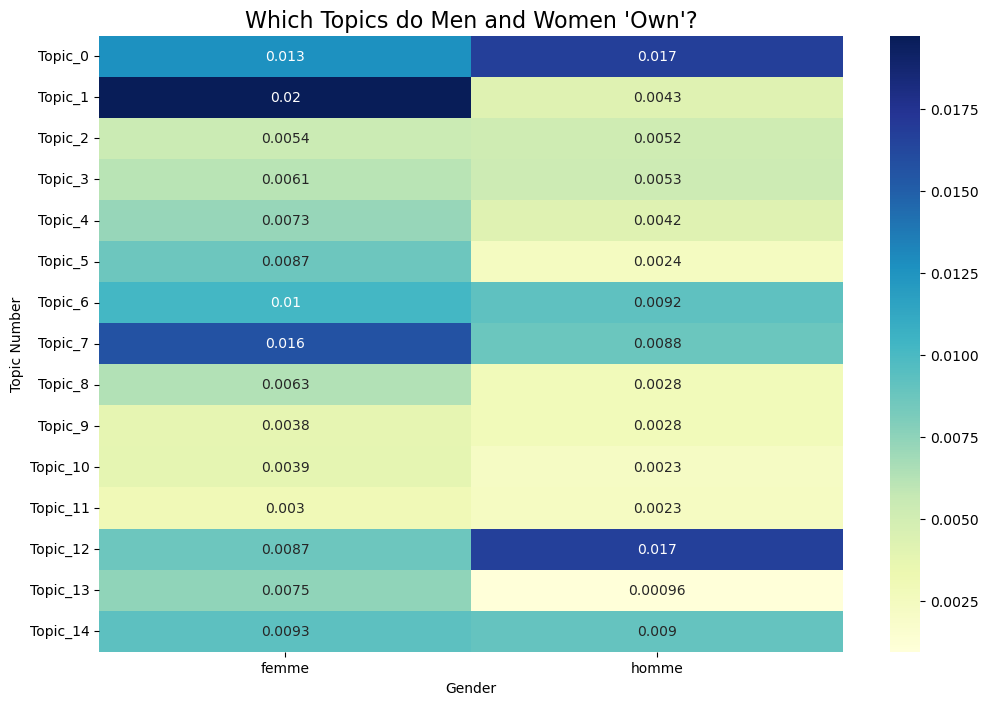

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(gender_topic_dist.T, annot=True, cmap="YlGnBu")
plt.title("Which Topics do Men and Women 'Own'?", fontsize=16)
plt.ylabel("Topic Number")
plt.xlabel("Gender")
plt.show()

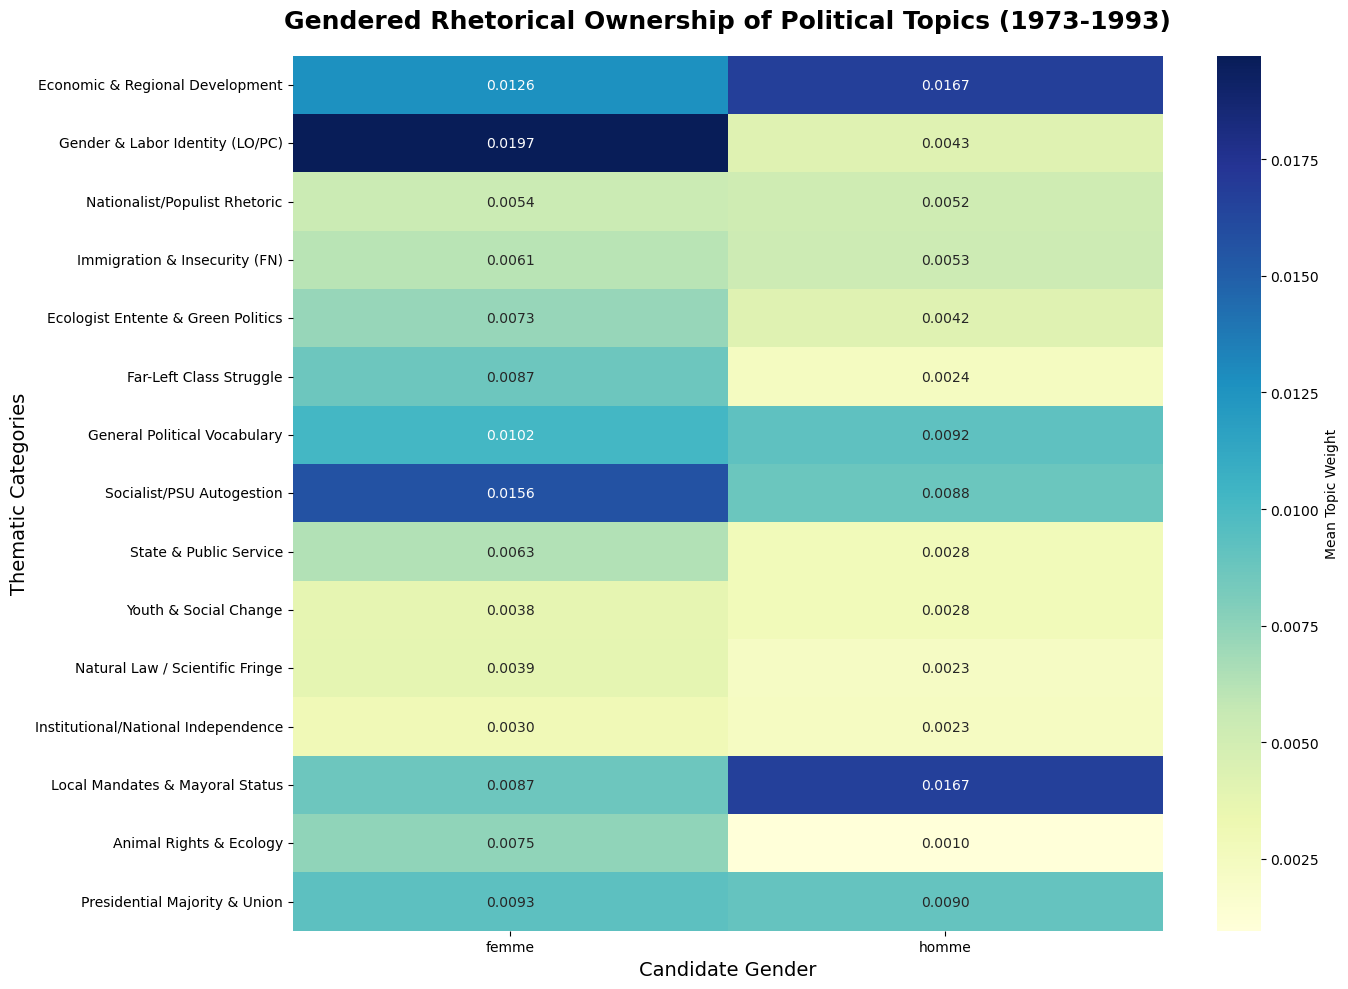

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define Topic names based on the word clusters
topic_map = {
    "Topic_0": "Economic & Regional Development",
    "Topic_1": "Gender & Labor Identity (LO/PC)",
    "Topic_2": "Nationalist/Populist Rhetoric",
    "Topic_3": "Immigration & Insecurity (FN)",
    "Topic_4": "Ecologist Entente & Green Politics",
    "Topic_5": "Far-Left Class Struggle",
    "Topic_6": "General Political Vocabulary",
    "Topic_7": "Socialist/PSU Autogestion",
    "Topic_8": "State & Public Service",
    "Topic_9": "Youth & Social Change",
    "Topic_10": "Natural Law / Scientific Fringe",
    "Topic_11": "Institutional/National Independence",
    "Topic_12": "Local Mandates & Mayoral Status",
    "Topic_13": "Animal Rights & Ecology",
    "Topic_14": "Presidential Majority & Union"
}

# Apply the names to results
gender_analysis = gender_topic_dist.copy()
gender_analysis.columns = [topic_map.get(col, col) for col in gender_analysis.columns]

# Create the Final Polished Heatmap
plt.figure(figsize=(14, 10))

# We transpose (.T) so topics are on the Y-axis for better reading
sns.heatmap(gender_analysis.T, 
            annot=True, 
            fmt=".4f", 
            cmap="YlGnBu", 
            cbar_kws={'label': 'Mean Topic Weight'})

plt.title("Gendered Rhetorical Ownership of Political Topics (1973-1993)", 
          fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Thematic Categories", fontsize=14)
plt.xlabel("Candidate Gender", fontsize=14)

# Adjusting layout to ensure names aren't cut off
plt.tight_layout()
plt.show()

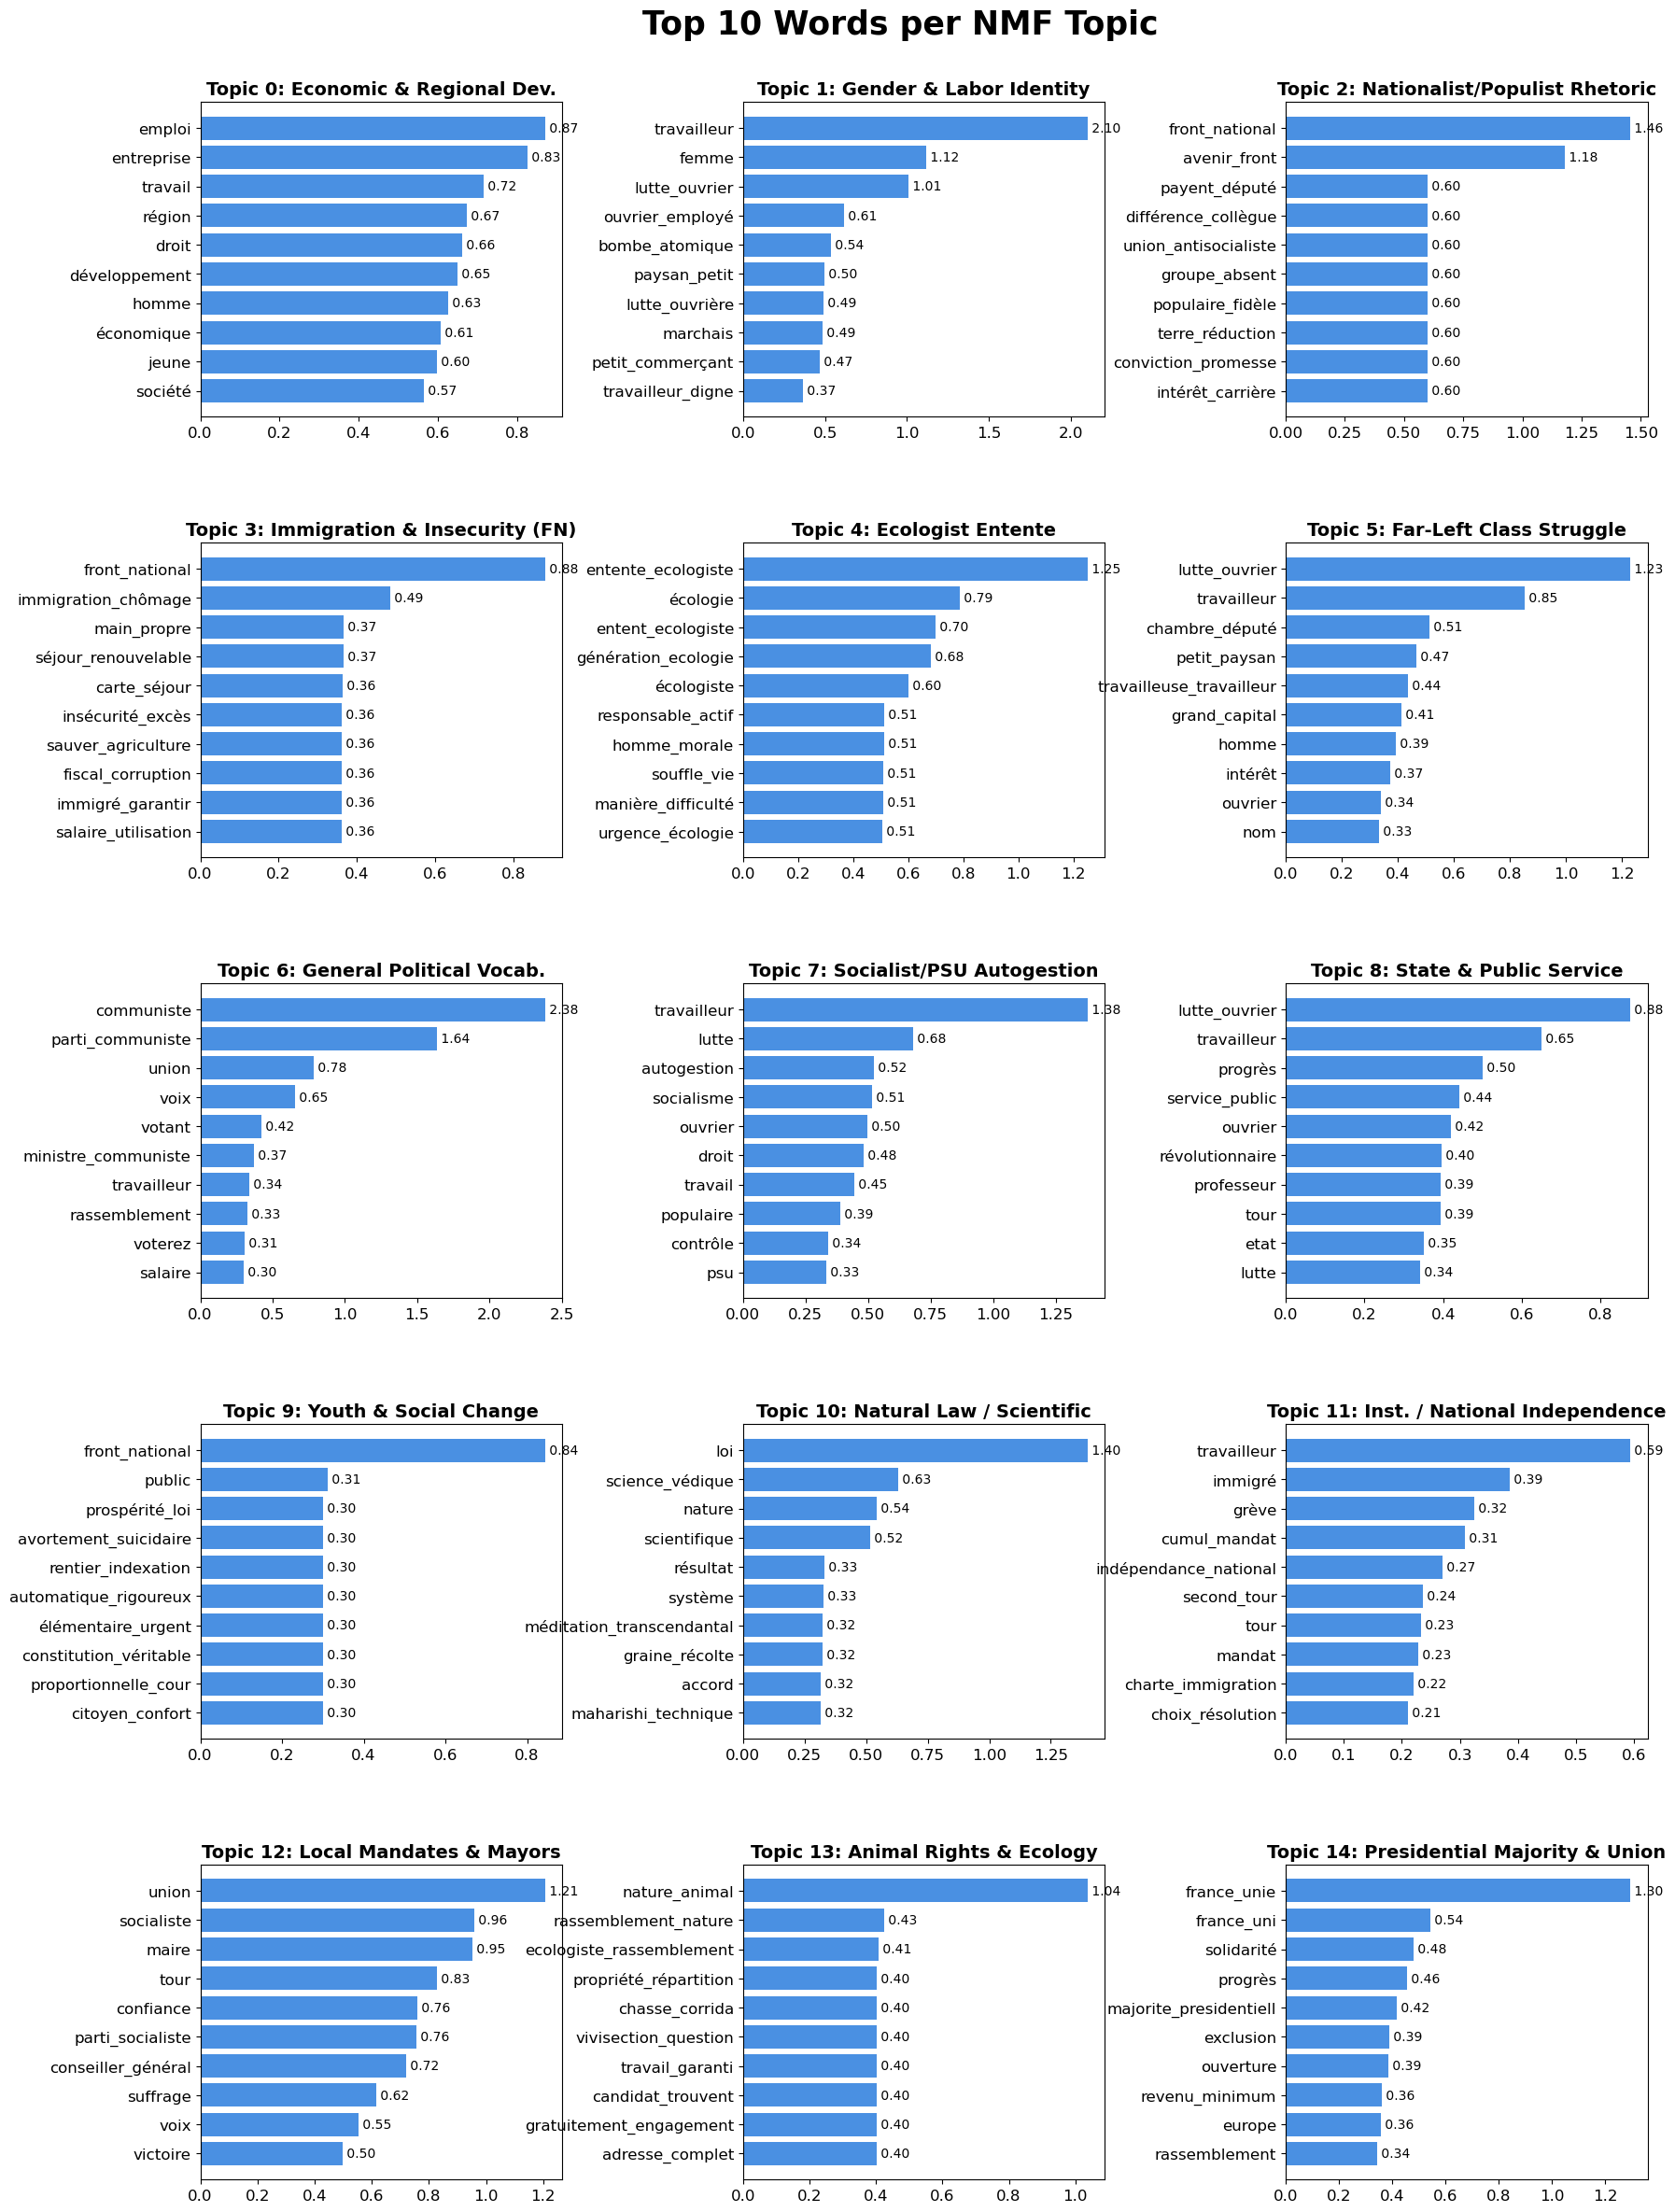

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Use the map created earlier
topic_map = {
    "Topic_0": "Economic & Regional Dev.",
    "Topic_1": "Gender & Labor Identity",
    "Topic_2": "Nationalist/Populist Rhetoric",
    "Topic_3": "Immigration & Insecurity (FN)",
    "Topic_4": "Ecologist Entente",
    "Topic_5": "Far-Left Class Struggle",
    "Topic_6": "General Political Vocab.",
    "Topic_7": "Socialist/PSU Autogestion",
    "Topic_8": "State & Public Service",
    "Topic_9": "Youth & Social Change",
    "Topic_10": "Natural Law / Scientific",
    "Topic_11": "Inst. / National Independence",
    "Topic_12": "Local Mandates & Mayors",
    "Topic_13": "Animal Rights & Ecology",
    "Topic_14": "Presidential Majority & Union"
}

def plot_top_words(model, feature_names, n_top_words, title, topic_names):
    fig, axes = plt.subplots(5, 3, figsize=(20, 25)) # Removed sharex=True for better weight visibility
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(model.components_):
        # Get the top words for this topic
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, color='#4a90e2')
        
        # Pull the name from our dictionary
        display_name = topic_names.get(f"Topic_{topic_idx}", f"Topic {topic_idx}")
        ax.set_title(f"Topic {topic_idx}: {display_name}", fontdict={"fontsize": 14, "fontweight": "bold"})
        
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
        
        # Add the weight value to the end of the bars for clarity
        for i, v in enumerate(weights):
            ax.text(v, i, f" {v:.2f}", va='center', fontsize=10)

    plt.subplots_adjust(top=0.94, bottom=0.05, wspace=0.5, hspace=0.4)
    fig.suptitle(title, fontsize=25, fontweight='bold')
    plt.show()

# Run the updated function
words = tfidf_vectorizer.get_feature_names_out()
plot_top_words(nmf_model, words, 10, "Top 10 Words per NMF Topic", topic_map)

Starting the Elbow Method calculation...
Completed k=2 | Error: 138.90
Completed k=5 | Error: 136.25
Completed k=10 | Error: 134.38
Completed k=15 | Error: 133.16
Completed k=20 | Error: 132.19
Completed k=25 | Error: 131.43
Completed k=30 | Error: 130.72
Completed k=40 | Error: 129.65


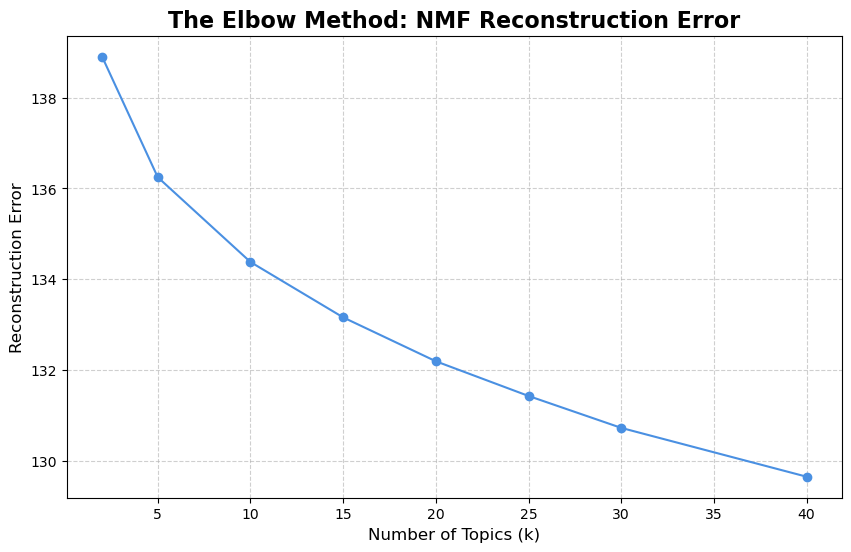

In [17]:
# Justification for using k=15 topics (Elbow Method)

import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

# Define the range of topics you want to test
topic_range = [2, 5, 10, 15, 20, 25, 30, 40]
errors = []

print("Starting the Elbow Method calculation...")

for k in topic_range:
    # Initialize NMF with the current k
    nmf = NMF(n_components=k, init='nndsvd', random_state=42, max_iter=400)
    nmf.fit(tfidf_matrix)
    
    # nmf.reconstruction_err_ gives the Frobenius norm of the matrix difference
    errors.append(nmf.reconstruction_err_)
    print(f"Completed k={k} | Error: {nmf.reconstruction_err_:.2f}")

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(topic_range, errors, marker='o', linestyle='-', color='#4a90e2')
plt.title('The Elbow Method: NMF Reconstruction Error', fontsize=16, fontweight='bold')
plt.xlabel('Number of Topics (k)', fontsize=12)
plt.ylabel('Reconstruction Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the "Elbow" area if it's visible
plt.show()

Sensitivity Analysis (k=10) training complete.

Top Words for k=10:


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9
0,maire,travailleur,front_national,front_national,entente_ecologiste,lutte_ouvrier,communiste,travailleur,lutte_ouvrier,front_national
1,homme,femme,avenir_front,immigration_chômage,écologie,travailleur,parti_communiste,lutte,travailleur,public
2,emploi,lutte_ouvrier,union_antisocialiste,main_propre,entent_ecologiste,chambre_député,union,droit,progrès,avortement_suicidaire
3,socialiste,ouvrier_employé,payent_député,séjour_renouvelable,génération_ecologie,petit_paysan,voix,travail,tour,prospérité_loi
4,région,bombe_atomique,différence_collègue,carte_séjour,écologiste,travailleuse_travailleur,victoire,autogestion,service_public,rentier_indexation
5,entreprise,paysan_petit,groupe_absent,insécurité_excès,responsable_actif,grand_capital,votant,ouvrier,ouvrier,élémentaire_urgent
6,confiance,lutte_ouvrière,populaire_fidèle,sauver_agriculture,homme_morale,homme,tour,socialisme,révolutionnaire,automatique_rigoureux
7,progrès,marchais,terre_réduction,fiscal_corruption,souffle_vie,intérêt,rassemblement,populaire,professeur,constitution_véritable
8,économique,petit_commerçant,conviction_promesse,immigré_garantir,manière_difficulté,ouvrier,ministre_communiste,salaire,lutte,proportionnelle_cour
9,développement,travailleur_digne,intérêt_carrière,salaire_utilisation,urgence_écologie,nom,parti_socialiste,femme,etat,citoyen_confort


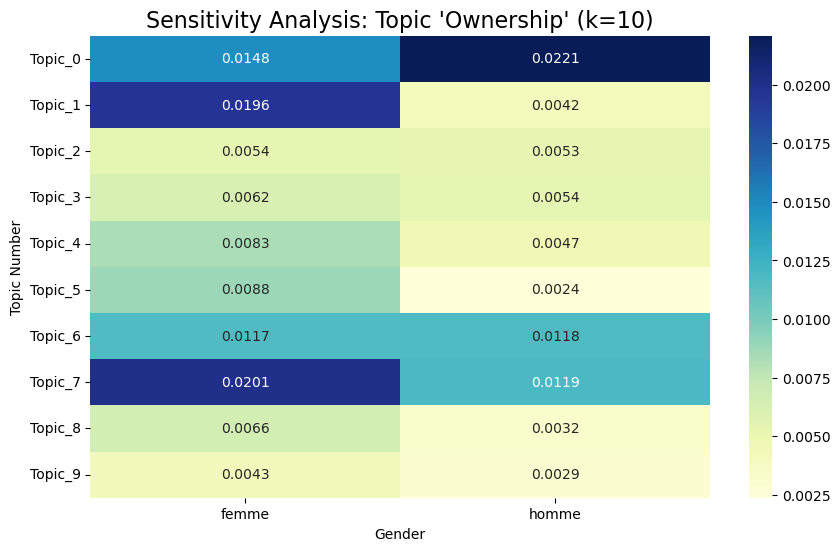

In [18]:
# --- Sensitivity Analysis: NMF with k=10 ---

num_topics_alt = 10

# 1. Initialize and fit the alternative model
nmf_model_10 = NMF(n_components=num_topics_alt, random_state=42, init='nndsvd')
W_10 = nmf_model_10.fit_transform(tfidf_matrix)
H_10 = nmf_model_10.components_

print(f"Sensitivity Analysis (k={num_topics_alt}) training complete.")

# 2. Get the Topic-Word Table for k=10
topics_df_10 = get_topic_words(tfidf_vectorizer, nmf_model_10)
print(f"\nTop Words for k={num_topics_alt}:")
display(topics_df_10) # Use display() in notebooks or print()

# 3. Create the weight DataFrame for k=10
weights_df_10 = pd.DataFrame(W_10, columns=[f"Topic_{i}" for i in range(num_topics_alt)])

# 4. Combine with original metadata (ensure df_modeling index is reset)
# Note: We use the already cleaned df_modeling from your previous step
df_final_10 = pd.concat([df_modeling.reset_index(drop=True), weights_df_10], axis=1)

# 5. Calculate average weights by gender
gender_topic_dist_10 = df_final_10.groupby('titulaire-sexe')[[f"Topic_{i}" for i in range(num_topics_alt)]].mean()

# 6. Visualization: Heatmap for k=10
plt.figure(figsize=(10, 6))
sns.heatmap(gender_topic_dist_10.T, annot=True, cmap="YlGnBu", fmt=".4f")
plt.title(f"Sensitivity Analysis: Topic 'Ownership' (k={num_topics_alt})", fontsize=16)
plt.ylabel("Topic Number")
plt.xlabel("Gender")
plt.show()

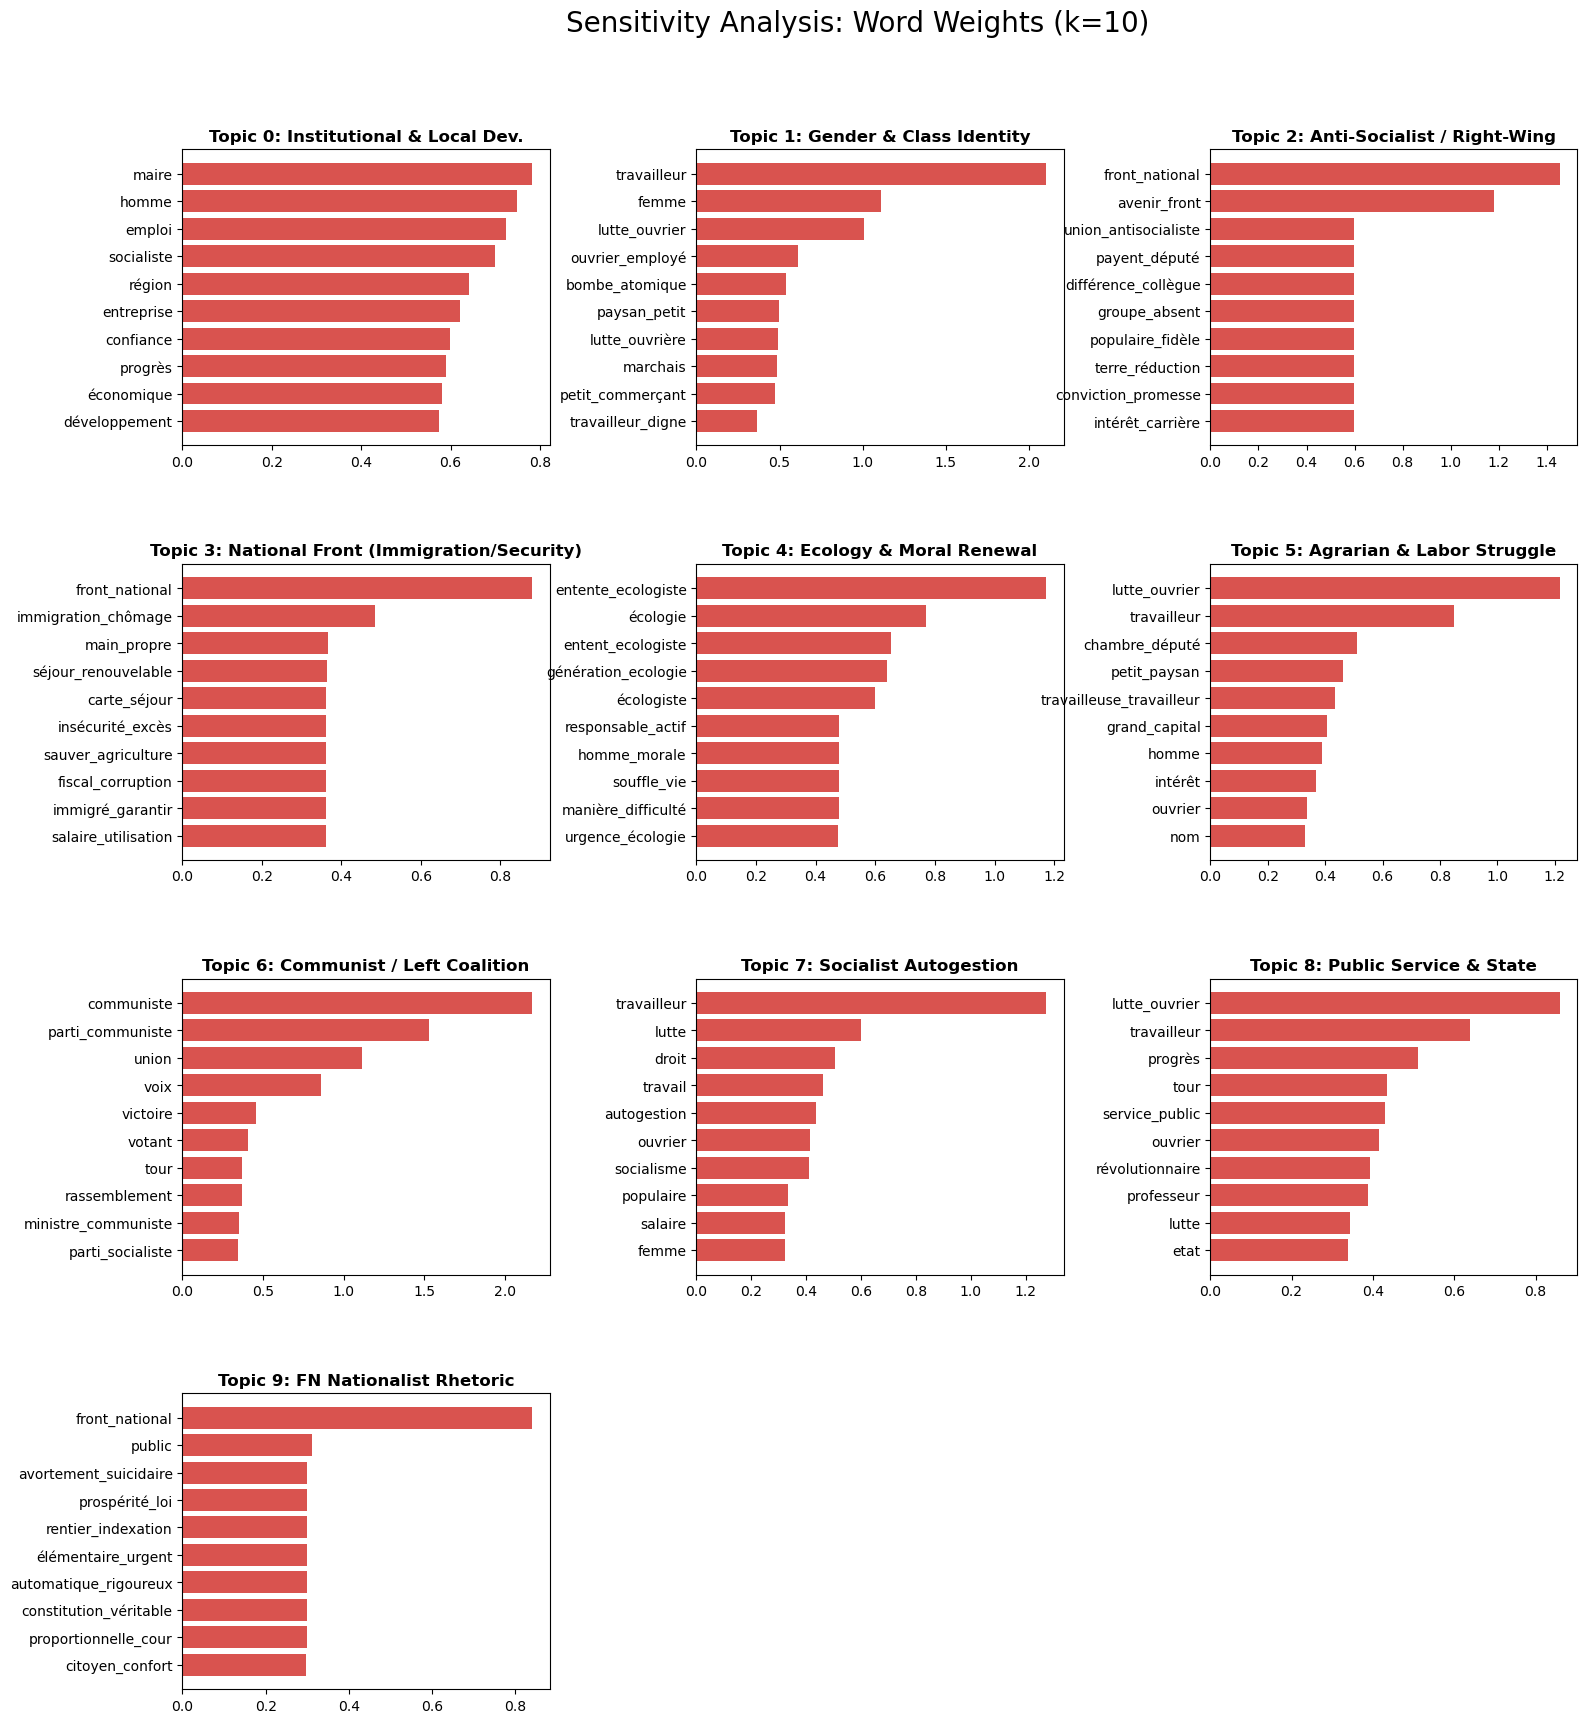

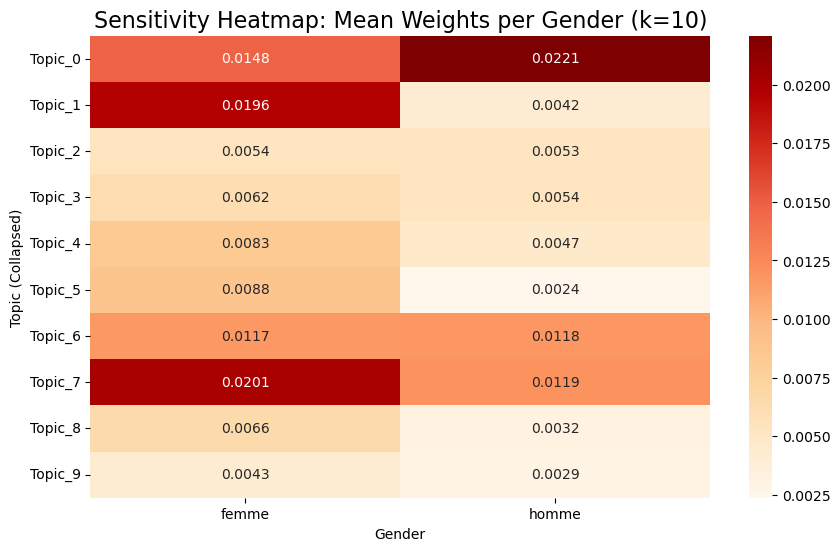

In [19]:
# New Mapping for k=10 based on your table
topic_map_10 = {
    "Topic_0": "Institutional & Local Dev.",
    "Topic_1": "Gender & Class Identity",
    "Topic_2": "Anti-Socialist / Right-Wing",
    "Topic_3": "National Front (Immigration/Security)",
    "Topic_4": "Ecology & Moral Renewal",
    "Topic_5": "Agrarian & Labor Struggle",
    "Topic_6": "Communist / Left Coalition",
    "Topic_7": "Socialist Autogestion",
    "Topic_8": "Public Service & State",
    "Topic_9": "FN Nationalist Rhetoric"
}

import matplotlib.pyplot as plt
import seaborn as sns

# A. The Bar Chart Grid for Sensitivity Analysis
def plot_sensitivity_topics(model, feature_names, n_top_words, topic_names):
    # 4 rows, 3 columns (since we have 10 topics)
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, color='#d9534f') # Different color to distinguish from k=15
        
        display_name = topic_names.get(f"Topic_{topic_idx}", f"Topic {topic_idx}")
        ax.set_title(f"Topic {topic_idx}: {display_name}", fontweight='bold')
        ax.invert_yaxis()

    # Hide the last two empty subplots
    for i in range(len(model.components_), len(axes)):
        fig.delaxes(axes[i])

    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.suptitle("Sensitivity Analysis: Word Weights (k=10)", fontsize=20, y=0.95)
    plt.show()

# Run Bar Charts
plot_sensitivity_topics(nmf_model_10, tfidf_vectorizer.get_feature_names_out(), 10, topic_map_10)

# B. The Heatmap for Sensitivity Analysis
plt.figure(figsize=(10, 6))
sns.heatmap(gender_topic_dist_10.T, annot=True, cmap="OrRd", fmt=".4f")
plt.title("Sensitivity Heatmap: Mean Weights per Gender (k=10)", fontsize=16)
plt.ylabel("Topic (Collapsed)")
plt.xlabel("Gender")
plt.show()

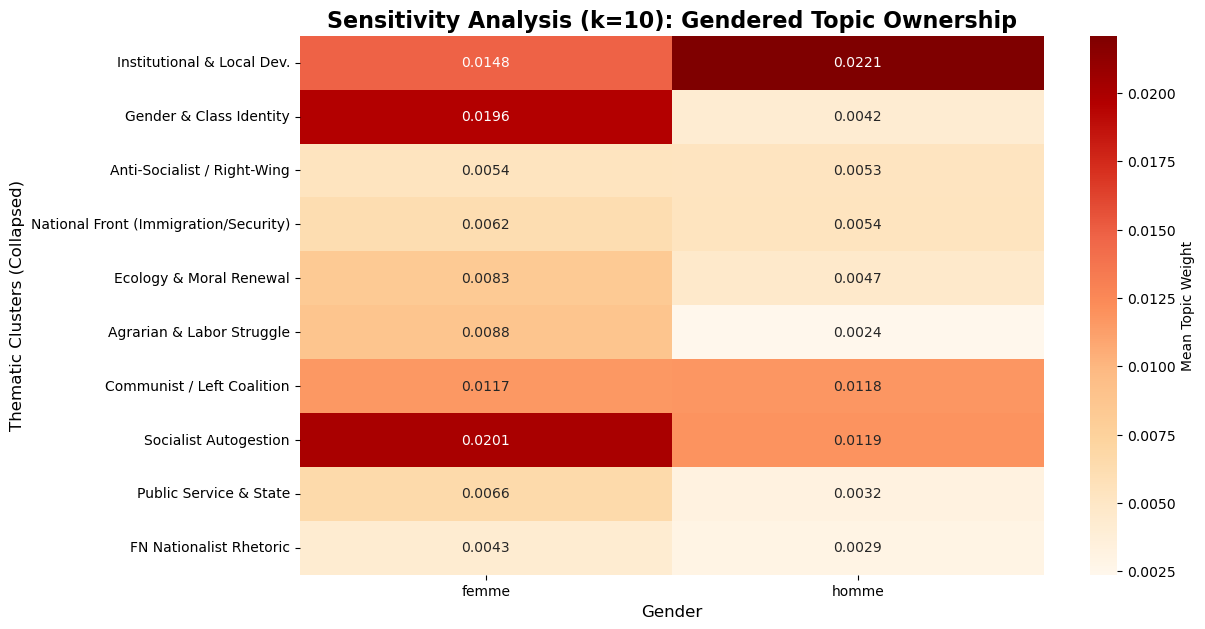

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data: Transpose and rename the index
heatmap_data_10 = gender_topic_dist_10.T

# 2. Map the Topic_X labels to your human-readable names
# We create a list of names in the correct order (0 to 9)
new_labels = [topic_map_10[f"Topic_{i}"] for i in range(len(topic_map_10))]
heatmap_data_10.index = new_labels

# 3. Plot the Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data_10, 
            annot=True, 
            cmap="OrRd", 
            fmt=".4f", 
            cbar_kws={'label': 'Mean Topic Weight'})

plt.title("Sensitivity Analysis (k=10): Gendered Topic Ownership", fontsize=16, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Thematic Clusters (Collapsed)", fontsize=12)

# Rotate labels for better readability if necessary
plt.xticks(rotation=0)
plt.show()